# 03i — E4 FSBI DWT Training

**Experiment:** E4 — Official FSBI frequency transformation integrated into the established E3b pipeline  
**Purpose:** Test whether DWT frequency enhancement improves cross-dataset generalisation relative to E3b official SBI.

This is a **controlled adaptation**, not a complete reproduction of the published EfficientNet-B5 FSBI system. It retains the E3b data, EfficientNet-B0 backbone, 224×224 input, optimiser, seed, epochs and model-selection rule. The only intended change is the published FSBI DWT transformation.

Internal evaluation belongs in `04i_E4_FFPP_Evaluation.ipynb`; Celeb-DF evaluation belongs in the corresponding Section 5 notebook.


## Experimental design

- **Research question:** Does wavelet-based frequency enhancement of official SBI improve generalisation to unseen deepfakes?
- **Hypothesis:** DWT-enhanced real and SBI images will expose frequency/texture patterns that transfer better from FF++ to Celeb-DF.
- **Control:** E3b Official SBI
- **Independent variable:** Published FSBI DWT transformation (`sym2`, `reflect`)
- **Controlled variables:** Clean video split, official SBI generation, source frames, EfficientNet-B0, ImageNet initialisation, 224×224 input, Adam, learning rate 0.0001, weight decay 0.0001, ten epochs, seed 42 and best-validation-AUC selection
- **Class treatment:** DWT is applied to both real (0) and synthetic fake (1), preventing DWT presence from becoming a class shortcut
- **External testing:** Celeb-DF only after training; no retraining, adaptation or threshold tuning
- **Checkpoint:** `saved_models/efficientnet_b0_fsbi_dwt_best.pth`

**Published source:** Hasanaath et al., *FSBI: Deepfake Detection with Frequency Enhanced Self-Blended Images*  
Paper: https://arxiv.org/abs/2406.08625  
Official code: https://github.com/gufranSabri/FSBI  
Audited reference commit: `c860ac3d47a71c20a55095a587e2c0790f763d85`


## 1. Safety control

Training is disabled by default. E4 uses new checkpoint, result and plot names and therefore does not overwrite E3b. If an E4 checkpoint already exists, explicit overwrite permission is required.


In [6]:
RUN_TRAINING = True
ALLOW_CHECKPOINT_OVERWRITE = False

CHECKPOINT_NAME = "efficientnet_b0_fsbi_dwt_best.pth"
RESULTS_NAME = "efficientnet_b0_fsbi_dwt_training_results.json"

print("E4 FSBI training enabled:", RUN_TRAINING)
print("Allow checkpoint overwrite:", ALLOW_CHECKPOINT_OVERWRITE)
print("E4 checkpoint:", CHECKPOINT_NAME)


E4 FSBI training enabled: True
Allow checkpoint overwrite: False
E4 checkpoint: efficientnet_b0_fsbi_dwt_best.pth


## 2. Independent environment and project validation

This modular training notebook mounts Google Drive independently. It does not require `00_Project_Setup.ipynb` to be rerun. The prepared SBI folders must already exist in Drive; this notebook validates them but does not recreate or modify them.

The official SBI repository is restored in Colab's temporary storage when necessary, and `PyWavelets` supplies the published DWT transformation.


In [7]:
import importlib.util
import os
import subprocess
import sys

from google.colab import drive

# Every modular notebook mounts Drive for itself. If it is already
# mounted, Colab reuses the existing mount without rebuilding data.
drive.mount("/content/drive", force_remount=False)

BASE_PATH = "/content/drive/MyDrive/deepfake_project"
SBI_BASE_PATH = os.path.join(BASE_PATH, "sbi_dataset")

required_paths = {
    "project root": BASE_PATH,
    "SBI train frames": os.path.join(
        SBI_BASE_PATH, "train", "frames", "real"
    ),
    "SBI train RetinaFace metadata": os.path.join(
        SBI_BASE_PATH, "train", "retina", "real"
    ),
    "SBI train landmarks": os.path.join(
        SBI_BASE_PATH, "train", "landmarks", "real"
    ),
    "SBI validation frames": os.path.join(
        SBI_BASE_PATH, "val", "frames", "real"
    ),
    "SBI validation RetinaFace metadata": os.path.join(
        SBI_BASE_PATH, "val", "retina", "real"
    ),
    "SBI validation landmarks": os.path.join(
        SBI_BASE_PATH, "val", "landmarks", "real"
    ),
}

missing_paths = [
    f"{name}: {path}"
    for name, path in required_paths.items()
    if not os.path.isdir(path)
]

if missing_paths:
    raise FileNotFoundError(
        "Required prepared project folders are missing:\n- "
        + "\n- ".join(missing_paths)
        + "\nRun the relevant preparation notebook before E4."
    )

print("Project root:", BASE_PATH)
print("Prepared SBI data:", SBI_BASE_PATH)

OFFICIAL_SBI_REPOSITORY = "/content/SelfBlendedImages"

if not os.path.isdir(OFFICIAL_SBI_REPOSITORY):
    subprocess.run(
        [
            "git",
            "clone",
            "https://github.com/mapooon/SelfBlendedImages.git",
            OFFICIAL_SBI_REPOSITORY,
        ],
        check=True,
    )
    print("Official SBI repository restored.")
else:
    print("Official SBI repository already available.")

if importlib.util.find_spec("pywt") is None:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "PyWavelets"],
        check=True,
    )

import pywt

print("PyWavelets version:", pywt.__version__)
print("FSBI wavelet: sym2")
print("FSBI boundary mode: reflect")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/deepfake_project
Prepared SBI data: /content/drive/MyDrive/deepfake_project/sbi_dataset
Official SBI repository already available.
PyWavelets version: 1.8.0
FSBI wavelet: sym2
FSBI boundary mode: reflect


In [4]:
from pathlib import Path

paths_to_check = [
    Path("/content/drive/MyDrive/deepfake_project"),
    Path("/content/drive/MyDrive/deepfake_project/sbi_dataset"),
    Path("/content/drive/MyDrive/deepfake_project/sbi_dataset/train"),
    Path("/content/drive/MyDrive/deepfake_project/sbi_dataset/train/frames"),
    Path("/content/drive/MyDrive/deepfake_project/sbi_dataset/train/frames/real"),
    Path("/content/drive/MyDrive/deepfake_project/sbi_dataset/train/retina/real"),
    Path("/content/drive/MyDrive/deepfake_project/sbi_dataset/train/landmarks/real"),
]

for path in paths_to_check:
    print(path, "->", path.exists())

/content/drive/MyDrive/deepfake_project -> True
/content/drive/MyDrive/deepfake_project/sbi_dataset -> True
/content/drive/MyDrive/deepfake_project/sbi_dataset/train -> True
/content/drive/MyDrive/deepfake_project/sbi_dataset/train/frames -> True
/content/drive/MyDrive/deepfake_project/sbi_dataset/train/frames/real -> True
/content/drive/MyDrive/deepfake_project/sbi_dataset/train/retina/real -> True
/content/drive/MyDrive/deepfake_project/sbi_dataset/train/landmarks/real -> True


In [5]:
import os

frames_path = (
    "/content/drive/MyDrive/deepfake_project/"
    "sbi_dataset/train/frames/real"
)

video_folders = os.listdir(frames_path)

print("Video folders accessible:", len(video_folders))
print("First five:", video_folders[:5])

Video folders accessible: 140
First five: ['01__exit_phone_room', '01__kitchen_pan', '01__kitchen_still', '01__meeting_serious', '01__outside_talking_pan_laughing']


## 3. Official SBI generation plus published FSBI transformation

Synthetic fakes are generated dynamically using the same E3b official SBI logic. After resizing and scaling to `[0,1]`, the published DWT transformation is applied separately to every RGB channel of **both** real and synthetic images.

For each channel, the approximation coefficient is resized and averaged with the original channel:

\[
C_{FSBI}=rac{C_{RGB}+\operatorname{Resize}(cA_C)}{2}
\]

The output remains a three-channel tensor. RGB order is preserved.


Official SBI helper functions imported successfully.
Official SBI train source frames: 1342
Official SBI val source frames: 290

FSBI batch shape: torch.Size([16, 3, 224, 224])
Official SBI label shape: torch.Size([16])
Labels: [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1]


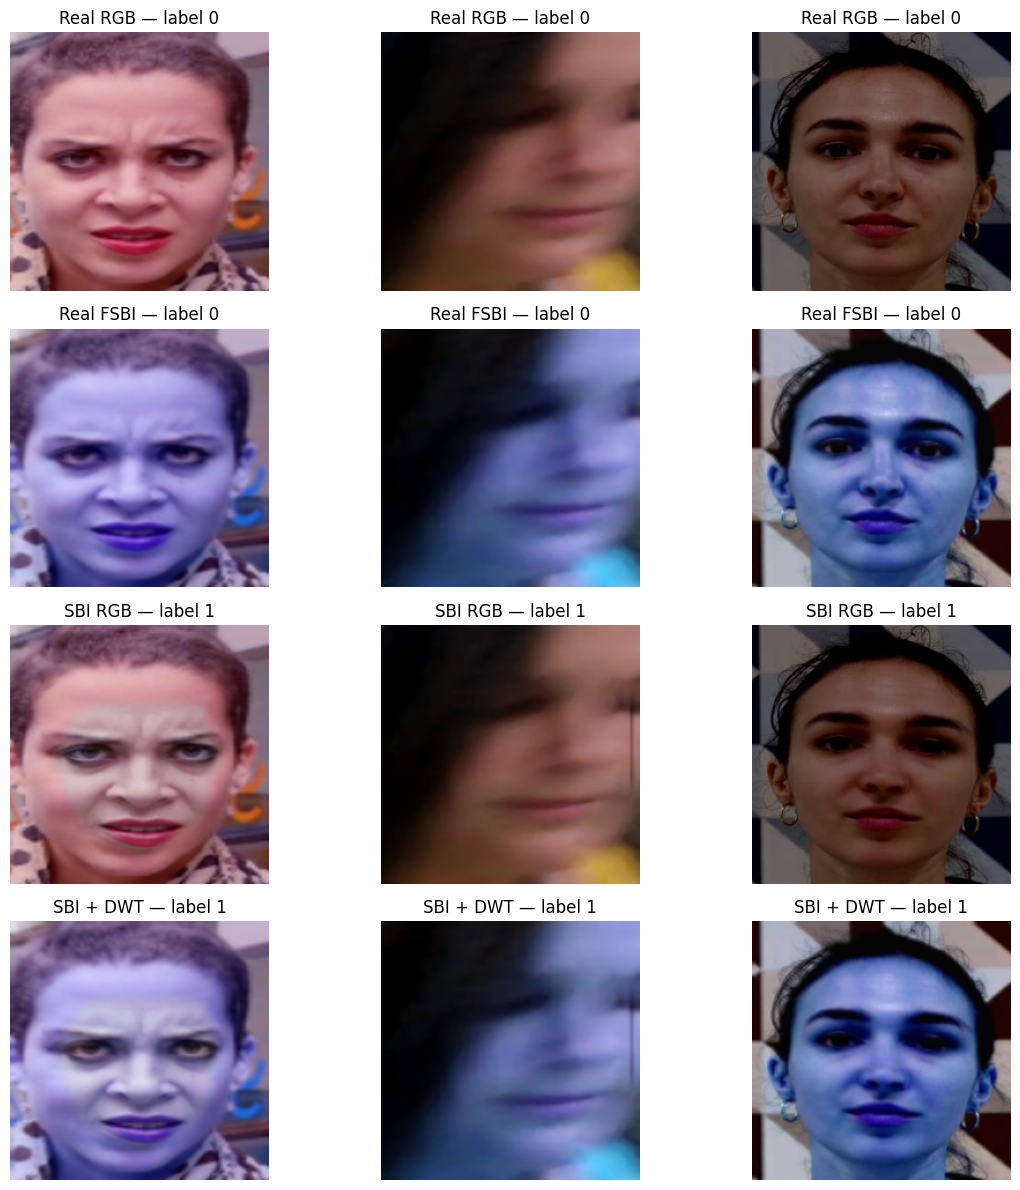

Mean absolute RGB-to-FSBI change: 0.210419
Raw FSBI value range: -0.029237 to 1.508275
Display note: FSBI panels are min-max scaled for plotting only.
PASS: DWT is applied to both classes and output remains finite 3-channel data.


In [8]:
# ============================================================
# E4: Official SBI + Published FSBI DWT on Our Dataset
#
# Uses OUR existing preprocessed dataset:
#   sbi_dataset/<split>/frames/real/
#   sbi_dataset/<split>/retina/real/
#   sbi_dataset/<split>/landmarks/real/
#
# Uses OFFICIAL SBI generation logic:
#   - official crop_face()
#   - official IoU face matching
#   - official landmark reordering and horizontal flip
#   - official source transforms
#   - official affine + elastic mask transformation
#   - official dynamic blending
#   - official paired post-blending augmentation
#
# No files are deleted or generated permanently.
# Synthetic images are created dynamically in memory.
# ============================================================

import os
import sys
import cv2
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
import albumentations as alb
import pywt

from PIL import Image
from torch.utils.data import Dataset, DataLoader


# ------------------------------------------------------------
# Paths and reproducibility
# ------------------------------------------------------------

base_path = "/content/drive/MyDrive/deepfake_project"
sbi_base = os.path.join(base_path, "sbi_dataset")

official_repo = "/content/SelfBlendedImages"
official_src = os.path.join(official_repo, "src")

if not os.path.exists(official_repo):
    raise RuntimeError(
        "Official SBI repository is missing from /content. "
        "Clone or restore SelfBlendedImages after restarting Colab."
    )

if official_src not in sys.path:
    sys.path.insert(0, official_src)

RANDOM_SEED = 42
IMAGE_SIZE = 224
FSBI_WAVELET = "sym2"
FSBI_MODE = "reflect"
FSBI_REFERENCE_REPOSITORY = "https://github.com/gufranSabri/FSBI"
FSBI_REFERENCE_COMMIT = "c860ac3d47a71c20a55095a587e2c0790f763d85"

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)


# ------------------------------------------------------------
# Import official SBI helper implementations
# ------------------------------------------------------------

from utils import blend as official_blend
from utils.funcs import (
    IoUfrom2bboxes,
    crop_face,
    RandomDownScale
)

print("Official SBI helper functions imported successfully.")


# ------------------------------------------------------------
# Albumentations compatibility helpers
#
# The official repository was written for an older version of
# Albumentations. These wrappers preserve the same parameters
# while supporting current Colab versions.
# ------------------------------------------------------------

def make_image_compression():
    import inspect

    parameters = inspect.signature(
        alb.ImageCompression.__init__
    ).parameters

    if "quality_range" in parameters:
        return alb.ImageCompression(
            quality_range=(40, 100),
            p=0.5
        )

    return alb.ImageCompression(
        quality_lower=40,
        quality_upper=100,
        p=0.5
    )


def make_elastic_transform():
    import inspect

    parameters = inspect.signature(
        alb.ElasticTransform.__init__
    ).parameters

    arguments = {
        "alpha": 50,
        "sigma": 7,
        "p": 1,
    }

    # The official legacy configuration used alpha_affine=0.
    # New releases removed this no-op argument.
    if "alpha_affine" in parameters:
        arguments["alpha_affine"] = 0

    return alb.ElasticTransform(**arguments)


# ------------------------------------------------------------
# Official-style SBI Dataset adapted only to our file paths
# ------------------------------------------------------------

class OfficialSBIWithFSBIDataset(Dataset):

    def __init__(
        self,
        root_path,
        phase="train",
        image_size=224
    ):
        assert phase in ["train", "val"]

        self.root_path = root_path
        self.phase = phase
        self.image_size = (
            image_size,
            image_size
        )

        self.frames_root = os.path.join(
            root_path,
            phase,
            "frames",
            "real"
        )

        self.retina_root = os.path.join(
            root_path,
            phase,
            "retina",
            "real"
        )

        self.landmarks_root = os.path.join(
            root_path,
            phase,
            "landmarks",
            "real"
        )

        self.samples = []

        for video_name in sorted(
            os.listdir(self.frames_root)
        ):
            frame_folder = os.path.join(
                self.frames_root,
                video_name
            )

            if not os.path.isdir(frame_folder):
                continue

            for frame_file in sorted(
                os.listdir(frame_folder)
            ):
                if not frame_file.lower().endswith(
                    ".png"
                ):
                    continue

                stem = os.path.splitext(
                    frame_file
                )[0]

                frame_path = os.path.join(
                    frame_folder,
                    frame_file
                )

                retina_path = os.path.join(
                    self.retina_root,
                    video_name,
                    stem + ".npy"
                )

                landmark_path = os.path.join(
                    self.landmarks_root,
                    video_name,
                    stem + ".npy"
                )

                if (
                    os.path.exists(frame_path)
                    and os.path.exists(retina_path)
                    and os.path.exists(landmark_path)
                ):
                    self.samples.append({
                        "frame": frame_path,
                        "retina": retina_path,
                        "landmarks": landmark_path
                    })

        self.transforms = self.get_transforms()
        self.source_transforms = (
            self.get_source_transforms()
        )

        print(
            f"Official SBI {phase} source frames:",
            len(self.samples)
        )

    def __len__(self):
        return len(self.samples)

    # --------------------------------------------------------
    # Published FSBI frequency transformation
    #
    # The official repository computes a one-level 2D DWT with
    # sym2/reflect, resizes cA, and averages it with the source
    # channel. This intentionally mirrors the authors' channel
    # construction: b, g, r unpacking followed by [cA_r, cA_g, cA_b].
    # --------------------------------------------------------

    def apply_fsbi_dwt(self, image_rgb):
        if image_rgb.ndim != 3 or image_rgb.shape[2] != 3:
            raise ValueError("FSBI expects an HxWx3 RGB image.")

        b, g, r = cv2.split(image_rgb)
        enhanced_channels = []

        for channel in (r, g, b):
            approximation, _ = pywt.dwt2(
                channel,
                FSBI_WAVELET,
                mode=FSBI_MODE,
            )

            approximation = cv2.resize(
                approximation,
                self.image_size,
                interpolation=cv2.INTER_LINEAR,
            ).astype(np.float32)

            enhanced = (
                approximation + channel.astype(np.float32)
            ) / 2.0

            enhanced_channels.append(enhanced)

        enhanced_rgb = np.stack(enhanced_channels, axis=2)

        if not np.isfinite(enhanced_rgb).all():
            raise ValueError("FSBI DWT produced non-finite values.")

        return enhanced_rgb.astype(np.float32)

    # --------------------------------------------------------
    # Official SBI source transformation
    # --------------------------------------------------------

    def get_source_transforms(self):
        return alb.Compose([
            alb.Compose([
                alb.RGBShift(
                    r_shift_limit=(-20, 20),
                    g_shift_limit=(-20, 20),
                    b_shift_limit=(-20, 20),
                    p=0.3
                ),

                alb.HueSaturationValue(
                    hue_shift_limit=(-0.3, 0.3),
                    sat_shift_limit=(-0.3, 0.3),
                    val_shift_limit=(-0.3, 0.3),
                    p=1
                ),

                alb.RandomBrightnessContrast(
                    brightness_limit=(-0.1, 0.1),
                    contrast_limit=(-0.1, 0.1),
                    p=1
                ),
            ], p=1),

            alb.OneOf([
                RandomDownScale(p=1),

                alb.Sharpen(
                    alpha=(0.2, 0.5),
                    lightness=(0.5, 1.0),
                    p=1
                ),
            ], p=1),
        ], p=1)

    # --------------------------------------------------------
    # Official paired transformation
    #
    # The same random post-blending changes are applied to both
    # the real and generated fake image.
    # --------------------------------------------------------

    def get_transforms(self):
        return alb.Compose([
            alb.RGBShift(
                r_shift_limit=(-20, 20),
                g_shift_limit=(-20, 20),
                b_shift_limit=(-20, 20),
                p=0.3
            ),

            alb.HueSaturationValue(
                hue_shift_limit=(-0.3, 0.3),
                sat_shift_limit=(-0.3, 0.3),
                val_shift_limit=(-0.3, 0.3),
                p=0.3
            ),

            alb.RandomBrightnessContrast(
                brightness_limit=(-0.3, 0.3),
                contrast_limit=(-0.3, 0.3),
                p=0.3
            ),

            make_image_compression(),
        ],
        additional_targets={
            "image1": "image"
        },
        p=1)

    # --------------------------------------------------------
    # Official affine and elastic transformation
    # --------------------------------------------------------

    def randaffine(
        self,
        image,
        mask
    ):
        affine_transform = alb.Affine(
            translate_percent={
                "x": (-0.03, 0.03),
                "y": (-0.015, 0.015)
            },
            scale=(0.95, 1 / 0.95),
            fit_output=False,
            p=1
        )

        elastic_transform = (
            make_elastic_transform()
        )

        transformed = affine_transform(
            image=image,
            mask=mask
        )

        image = transformed["image"]
        mask = transformed["mask"]

        transformed = elastic_transform(
            image=image,
            mask=mask
        )

        mask = transformed["mask"]

        return image, mask

    # --------------------------------------------------------
    # Official landmark ordering
    # --------------------------------------------------------

    def reorder_landmark(
        self,
        landmark
    ):
        landmark = landmark.copy()

        landmark_add = np.zeros(
            (13, 2),
            dtype=landmark.dtype
        )

        official_order = [
            77, 75, 76, 68, 69, 70, 71,
            80, 72, 73, 79, 74, 78
        ]

        for new_index, old_index in enumerate(
            official_order
        ):
            landmark_add[new_index] = (
                landmark[old_index]
            )

        landmark[68:] = landmark_add

        return landmark

    # --------------------------------------------------------
    # Official horizontal flip
    #
    # This mirrors coordinates and reorders anatomical indices.
    # --------------------------------------------------------

    def hflip(
        self,
        image,
        mask=None,
        landmark=None,
        bbox=None
    ):
        height, width = image.shape[:2]

        landmark_new = None
        bbox_new = None

        if landmark is not None:
            landmark = landmark.copy()
            landmark_new = np.zeros_like(
                landmark
            )

            landmark_new[:17] = (
                landmark[:17][::-1]
            )

            landmark_new[17:27] = (
                landmark[17:27][::-1]
            )

            landmark_new[27:31] = (
                landmark[27:31]
            )

            landmark_new[31:36] = (
                landmark[31:36][::-1]
            )

            landmark_new[36:40] = (
                landmark[42:46][::-1]
            )

            landmark_new[40:42] = (
                landmark[46:48][::-1]
            )

            landmark_new[42:46] = (
                landmark[36:40][::-1]
            )

            landmark_new[46:48] = (
                landmark[40:42][::-1]
            )

            landmark_new[48:55] = (
                landmark[48:55][::-1]
            )

            landmark_new[55:60] = (
                landmark[55:60][::-1]
            )

            landmark_new[60:65] = (
                landmark[60:65][::-1]
            )

            landmark_new[65:68] = (
                landmark[65:68][::-1]
            )

            if len(landmark) == 81:
                landmark_new[68:81] = (
                    landmark[68:81][::-1]
                )

            elif len(landmark) != 68:
                raise NotImplementedError(
                    "Expected 68 or 81 landmarks."
                )

            landmark_new[:, 0] = (
                width - landmark_new[:, 0]
            )

        if bbox is not None:
            bbox = bbox.copy()
            bbox_new = np.zeros_like(bbox)

            bbox_new[0, 0] = bbox[1, 0]
            bbox_new[1, 0] = bbox[0, 0]

            bbox_new[:, 0] = (
                width - bbox_new[:, 0]
            )

            bbox_new[:, 1] = (
                bbox[:, 1].copy()
            )

            if len(bbox) > 2:
                bbox_new[2, 0] = (
                    width - bbox[3, 0]
                )
                bbox_new[2, 1] = bbox[3, 1]

                bbox_new[3, 0] = (
                    width - bbox[2, 0]
                )
                bbox_new[3, 1] = bbox[2, 1]

                bbox_new[4, 0] = (
                    width - bbox[4, 0]
                )
                bbox_new[4, 1] = bbox[4, 1]

                bbox_new[5, 0] = (
                    width - bbox[6, 0]
                )
                bbox_new[5, 1] = bbox[6, 1]

                bbox_new[6, 0] = (
                    width - bbox[5, 0]
                )
                bbox_new[6, 1] = bbox[5, 1]

        if mask is not None:
            mask = mask[:, ::-1]

        image = image[:, ::-1].copy()

        return (
            image,
            mask,
            landmark_new,
            bbox_new
        )

    # --------------------------------------------------------
    # Official self-blending logic
    #
    # Because the optional BI mask library is not included in
    # the public repository, this uses the official fallback:
    # cv2.convexHull over the dense landmarks.
    # --------------------------------------------------------

    def self_blending(
        self,
        image,
        landmark
    ):
        mask = np.zeros_like(
            image[:, :, 0],
            dtype=np.float32
        )

        if np.random.rand() < 0.25:
            landmark_for_mask = landmark[:68]
        else:
            landmark_for_mask = landmark

        cv2.fillConvexPoly(
            mask,
            cv2.convexHull(
                landmark_for_mask.astype(
                    np.int32
                )
            ),
            1.0
        )

        source = image.copy()
        target = image.copy()

        # Official code randomly transforms source or target.
        if np.random.rand() < 0.5:
            source = self.source_transforms(
                image=source.astype(np.uint8)
            )["image"]

        else:
            target = self.source_transforms(
                image=target.astype(np.uint8)
            )["image"]

        source, mask = self.randaffine(
            source,
            mask
        )

        blended, mask = (
            official_blend.dynamic_blend(
                source,
                target,
                mask
            )
        )

        blended = blended.astype(np.uint8)
        target = target.astype(np.uint8)

        return target, blended, mask

    # --------------------------------------------------------
    # Load and dynamically generate one official SBI pair
    # --------------------------------------------------------

    def _generate_pair(
        self,
        index
    ):
        sample = self.samples[index]

        image = np.array(
            Image.open(sample["frame"])
            .convert("RGB")
        )

        landmark_array = np.load(
            sample["landmarks"]
        )

        retina_array = np.load(
            sample["retina"]
        )

        landmark = (
            landmark_array[0]
            .astype(np.float32)
        )

        # Dense-landmark bounding rectangle
        bbox_landmark = np.array([
            landmark[:, 0].min(),
            landmark[:, 1].min(),
            landmark[:, 0].max(),
            landmark[:, 1].max()
        ])

        # Select RetinaFace box with highest IoU.
        maximum_iou = -1
        bbox = None

        for candidate in retina_array:
            candidate_iou = (
                IoUfrom2bboxes(
                    bbox_landmark,
                    candidate.flatten()[:4]
                )
            )

            if candidate_iou > maximum_iou:
                bbox = candidate.copy()
                maximum_iou = candidate_iou

        if bbox is None:
            raise RuntimeError(
                "No RetinaFace box matched landmarks."
            )

        landmark = self.reorder_landmark(
            landmark
        )

        # Official random training flip.
        if (
            self.phase == "train"
            and np.random.rand() < 0.5
        ):
            (
                image,
                _,
                landmark,
                bbox
            ) = self.hflip(
                image,
                None,
                landmark,
                bbox
            )

        # Official enlarged working crop.
        (
            image,
            landmark,
            bbox,
            _
        ) = crop_face(
            image,
            landmark,
            bbox,
            margin=True,
            crop_by_bbox=False,
            phase=self.phase
        )

        # Generate official SBI pair.
        image_real, image_fake, _ = (
            self.self_blending(
                image.copy(),
                landmark.copy()
            )
        )

        # Official paired post-blending augmentation.
        if self.phase == "train":
            transformed = self.transforms(
                image=image_fake.astype(
                    np.uint8
                ),
                image1=image_real.astype(
                    np.uint8
                )
            )

            image_fake = transformed["image"]
            image_real = transformed["image1"]

        # Official final crop from generated fake.
        (
            image_fake,
            _,
            _,
            _,
            y0,
            y1,
            x0,
            x1
        ) = crop_face(
            image_fake,
            landmark,
            bbox,
            margin=False,
            crop_by_bbox=True,
            abs_coord=True,
            phase=self.phase
        )

        # Apply identical coordinates to real image.
        image_real = image_real[
            y0:y1,
            x0:x1
        ]

        if (
            image_fake.size == 0
            or image_real.size == 0
        ):
            raise ValueError(
                "Official SBI created empty crop."
            )

        # Official SBI output is resized and divided by 255.
        image_fake = cv2.resize(
            image_fake,
            self.image_size,
            interpolation=cv2.INTER_LINEAR
        ).astype(np.float32) / 255.0

        image_real = cv2.resize(
            image_real,
            self.image_size,
            interpolation=cv2.INTER_LINEAR
        ).astype(np.float32) / 255.0

        # Keep RGB copies for the visual validity check.
        image_fake_rgb = image_fake.copy()
        image_real_rgb = image_real.copy()

        # Apply the published FSBI transform to BOTH classes.
        image_fake_fsbi = self.apply_fsbi_dwt(image_fake_rgb)
        image_real_fsbi = self.apply_fsbi_dwt(image_real_rgb)

        def to_tensor(image):
            return torch.tensor(
                image.transpose(2, 0, 1),
                dtype=torch.float32,
            )

        return (
            to_tensor(image_fake_fsbi),
            to_tensor(image_real_fsbi),
            to_tensor(image_fake_rgb),
            to_tensor(image_real_rgb),
        )

    def __getitem__(
        self,
        index
    ):
        # Keep validation output deterministic.
        if self.phase == "val":
            python_state = random.getstate()
            numpy_state = np.random.get_state()

            random.seed(
                RANDOM_SEED + index
            )
            np.random.seed(
                RANDOM_SEED + index
            )

        try:
            fake_tensor, real_tensor, fake_rgb, real_rgb = (
                self._generate_pair(index)
            )

        except Exception as error:
            replacement_index = random.randrange(
                len(self.samples)
            )

            print(
                f"Official SBI sample error at "
                f"index {index}: {error}. "
                f"Using replacement index "
                f"{replacement_index}."
            )

            fake_tensor, real_tensor, fake_rgb, real_rgb = (
                self._generate_pair(
                    replacement_index
                )
            )

        if self.phase == "val":
            random.setstate(
                python_state
            )
            np.random.set_state(
                numpy_state
            )

        return fake_tensor, real_tensor, fake_rgb, real_rgb


# ------------------------------------------------------------
# Official collate logic
# ------------------------------------------------------------

def fsbi_collate_fn(batch):
    fake_fsbi, real_fsbi, fake_rgb, real_rgb = zip(*batch)

    real_batch = torch.stack(real_fsbi)
    fake_batch = torch.stack(fake_fsbi)

    images = torch.cat([real_batch, fake_batch], dim=0)
    rgb_images = torch.cat(
        [torch.stack(real_rgb), torch.stack(fake_rgb)],
        dim=0,
    )

    labels = torch.tensor(
        [0] * len(real_fsbi) + [1] * len(fake_fsbi),
        dtype=torch.long,
    )

    return {
        "images": images,
        "rgb_images": rgb_images,
        "labels": labels,
    }


# ------------------------------------------------------------
# Create E4 loaders
# ------------------------------------------------------------

fsbi_train_dataset = (
    OfficialSBIWithFSBIDataset(
        sbi_base,
        phase="train",
        image_size=IMAGE_SIZE
    )
)

fsbi_val_dataset = (
    OfficialSBIWithFSBIDataset(
        sbi_base,
        phase="val",
        image_size=IMAGE_SIZE
    )
)

# Eight source frames produce:
# 8 real + 8 official SBI fake = 16 model inputs.
FSBI_SOURCE_BATCH_SIZE = 8

fsbi_train_loader = DataLoader(
    fsbi_train_dataset,
    batch_size=FSBI_SOURCE_BATCH_SIZE,
    shuffle=True,
    collate_fn=fsbi_collate_fn,
    num_workers=0,
    pin_memory=True,
    drop_last=True
)

fsbi_val_loader = DataLoader(
    fsbi_val_dataset,
    batch_size=FSBI_SOURCE_BATCH_SIZE,
    shuffle=False,
    collate_fn=fsbi_collate_fn,
    num_workers=0,
    pin_memory=True
)


# ------------------------------------------------------------
# Sanity-check one official SBI batch
# ------------------------------------------------------------

fsbi_batch = next(
    iter(fsbi_train_loader)
)

print()
print(
    "FSBI batch shape:",
    fsbi_batch["images"].shape
)

print(
    "Official SBI label shape:",
    fsbi_batch["labels"].shape
)

print(
    "Labels:",
    fsbi_batch["labels"].tolist()
)


# ------------------------------------------------------------
# Visual validity check: RGB input versus FSBI representation
# Official FSBI training values may exceed 1. Only the plotted FSBI
# copy is min-max scaled; the tensor passed to the model is unchanged.
# ------------------------------------------------------------

number_of_pairs = 3
plt.figure(figsize=(12, 12))

for pair_index in range(number_of_pairs):
    indices = [
        pair_index,
        FSBI_SOURCE_BATCH_SIZE + pair_index,
    ]

    images_to_show = [
        fsbi_batch["rgb_images"][indices[0]],
        fsbi_batch["images"][indices[0]],
        fsbi_batch["rgb_images"][indices[1]],
        fsbi_batch["images"][indices[1]],
    ]

    titles = [
        "Real RGB — label 0",
        "Real FSBI — label 0",
        "SBI RGB — label 1",
        "SBI + DWT — label 1",
    ]

    for row_index, (image_tensor, title) in enumerate(
        zip(images_to_show, titles)
    ):
        image = image_tensor.cpu().numpy().transpose(1, 2, 0)
        if "FSBI" in title or "DWT" in title:
            display_minimum = image.min()
            display_maximum = image.max()
            image = (image - display_minimum) / (
                display_maximum - display_minimum + 1e-8
            )
        plt.subplot(4, number_of_pairs, row_index * number_of_pairs + pair_index + 1)
        plt.imshow(np.clip(image, 0, 1))
        plt.title(title)
        plt.axis("off")

plt.tight_layout()
plt.show()

assert fsbi_batch["images"].shape == fsbi_batch["rgb_images"].shape
assert torch.isfinite(fsbi_batch["images"]).all()
assert fsbi_batch["images"].shape[1:] == (3, IMAGE_SIZE, IMAGE_SIZE)
assert fsbi_batch["labels"].tolist() == (
    [0] * FSBI_SOURCE_BATCH_SIZE + [1] * FSBI_SOURCE_BATCH_SIZE
)

mean_absolute_change = (
    fsbi_batch["images"] - fsbi_batch["rgb_images"]
).abs().mean().item()

print("Mean absolute RGB-to-FSBI change:", f"{mean_absolute_change:.6f}")
print(
    "Raw FSBI value range:",
    f"{fsbi_batch['images'].min().item():.6f}",
    "to",
    f"{fsbi_batch['images'].max().item():.6f}",
)
print("Display note: FSBI panels are min-max scaled for plotting only.")
print("PASS: DWT is applied to both classes and output remains finite 3-channel data.")


## 4. Train and save E4

This cell trains the controlled EfficientNet-B0 model and selects the checkpoint with the highest synthetic validation ROC-AUC. It writes only E4-specific artifacts.


Using device: cuda
GPU: Tesla T4
Real training source frames: 1342
Real validation source frames: 290
Source batch size: 8
Effective model batch size: 16
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 197MB/s]


Trainable parameters: 4,010,110
Epoch 1 Batch 0/167 Loss: 0.7050
Epoch 1 Batch 20/167 Loss: 0.6010
Epoch 1 Batch 40/167 Loss: 0.5646
Epoch 1 Batch 60/167 Loss: 0.5320
Epoch 1 Batch 80/167 Loss: 0.6143
Epoch 1 Batch 100/167 Loss: 0.4657
Epoch 1 Batch 120/167 Loss: 0.3352
Epoch 1 Batch 140/167 Loss: 0.2959
Epoch 1 Batch 160/167 Loss: 0.2566

Epoch [1/10]
Train Loss: 0.5106 | Train Acc: 73.50% | Train Precision: 73.54% | Train Recall: 73.50% | Train F1: 73.49% | Train AUC: 0.8282
Val Loss: 0.3843 | Val Acc: 81.38% | Val Precision: 81.67% | Val Recall: 81.38% | Val F1: 81.34% | Val AUC: 0.8991
Learning rate: 0.00010000
Epoch time: 72.83 minutes
*** Best E4 FSBI model updated at Epoch 1 | Val AUC: 0.8991 | Val Accuracy: 81.38% | Val F1: 81.34% ***
---------------------------------------------------------------------------
Epoch 2 Batch 0/167 Loss: 0.7923
Epoch 2 Batch 20/167 Loss: 0.2311
Epoch 2 Batch 40/167 Loss: 0.4282
Epoch 2 Batch 60/167 Loss: 0.4007
Epoch 2 Batch 80/167 Loss: 0.3565
Ep

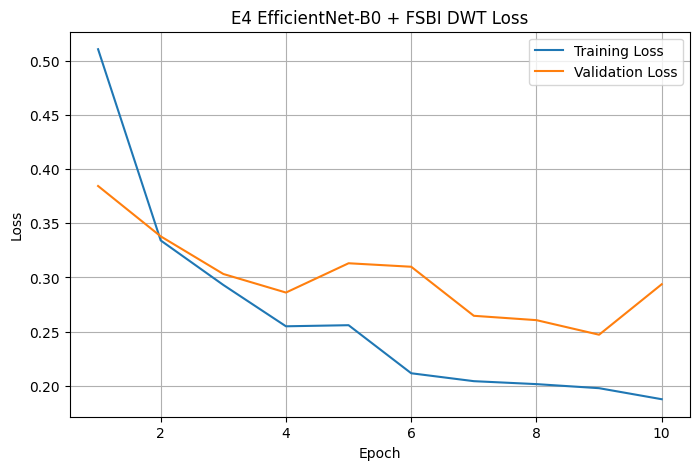

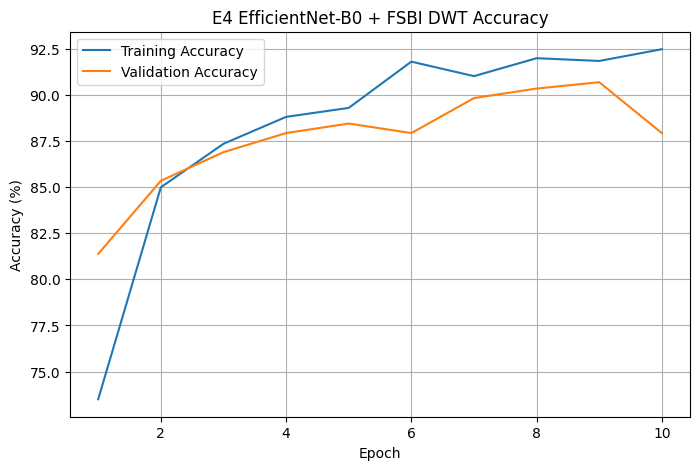

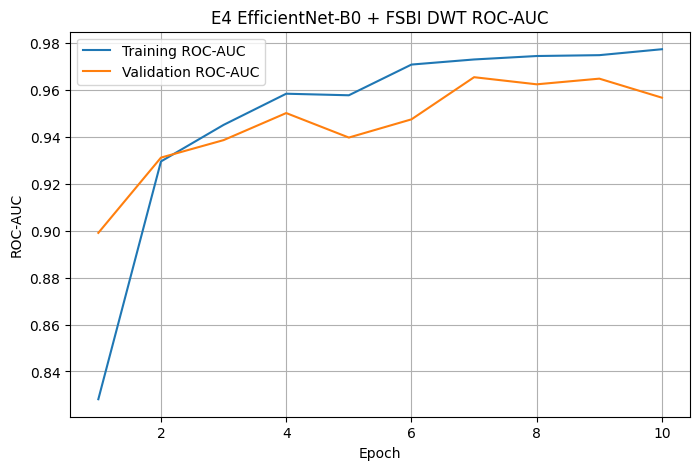

In [9]:
# ============================================================
# E4: EfficientNet-B0 with Official SBI + FSBI DWT
#
# Training source:
#   Real FF++ training frames only
#
# Dynamic training pairs:
#   Original real image -> label 0
#   Official SBI + DWT -> label 1
#
# Validation:
#   Real validation frames + dynamically generated SBI fakes
#
# Backbone:
#   ImageNet-pretrained EfficientNet-B0
#   Full fine-tuning
#
# Model selection:
#   Best validation ROC-AUC
#
# Safety:
#   Does not overwrite the previous E3a model or results.
# ============================================================

if RUN_TRAINING:
    import os
    import json
    import time
    import random
    import numpy as np
    import torch
    import torch.nn as nn
    import torch.optim as optim
    import matplotlib.pyplot as plt

    from torchvision.models import (
        efficientnet_b0,
        EfficientNet_B0_Weights
    )

    from sklearn.metrics import (
        accuracy_score,
        precision_score,
        recall_score,
        f1_score,
        roc_auc_score
    )

    # --------------------------------------------------------
    # Paths
    # --------------------------------------------------------

    base_path = "/content/drive/MyDrive/deepfake_project"

    model_dir = os.path.join(
        base_path,
        "saved_models"
    )

    results_dir = os.path.join(
        base_path,
        "results"
    )

    plots_dir = os.path.join(
        base_path,
        "plots"
    )

    os.makedirs(
        model_dir,
        exist_ok=True
    )

    os.makedirs(
        results_dir,
        exist_ok=True
    )

    os.makedirs(
        plots_dir,
        exist_ok=True
    )

    model_path = os.path.join(
        model_dir,
        "efficientnet_b0_fsbi_dwt_best.pth"
    )

    results_path = os.path.join(
        results_dir,
        "efficientnet_b0_fsbi_dwt_training_results.json"
    )

    if (
        RUN_TRAINING
        and os.path.exists(model_path)
        and not ALLOW_CHECKPOINT_OVERWRITE
    ):
        raise FileExistsError(
            f"E4 checkpoint already exists: {model_path}. "
            "Set ALLOW_CHECKPOINT_OVERWRITE = True only if replacement is intentional."
        )

    # --------------------------------------------------------
    # Device
    # --------------------------------------------------------

    device = torch.device(
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )

    print("Using device:", device)

    if torch.cuda.is_available():
        print(
            "GPU:",
            torch.cuda.get_device_name(0)
        )

        torch.cuda.empty_cache()

    # --------------------------------------------------------
    # Confirm required loaders exist
    # --------------------------------------------------------

    required_objects = [
        "fsbi_train_loader",
        "fsbi_val_loader",
        "FSBI_SOURCE_BATCH_SIZE"
    ]

    missing_objects = [
        name
        for name in required_objects
        if name not in globals()
    ]

    if missing_objects:
        raise RuntimeError(
            "Run the official SBI loader cell first. "
            f"Missing objects: {missing_objects}"
        )

    print(
        "Real training source frames:",
        len(fsbi_train_loader.dataset)
    )

    print(
        "Real validation source frames:",
        len(fsbi_val_loader.dataset)
    )

    print(
        "Source batch size:",
        FSBI_SOURCE_BATCH_SIZE
    )

    print(
        "Effective model batch size:",
        FSBI_SOURCE_BATCH_SIZE * 2
    )

    # --------------------------------------------------------
    # Reproducibility
    # --------------------------------------------------------

    RANDOM_SEED = 42

    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)
    torch.manual_seed(RANDOM_SEED)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(
            RANDOM_SEED
        )

    # --------------------------------------------------------
    # Training configuration
    # --------------------------------------------------------

    NUM_EPOCHS = 10
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY = 1e-4

    # --------------------------------------------------------
    # Model
    # --------------------------------------------------------

    weights = EfficientNet_B0_Weights.DEFAULT

    model = efficientnet_b0(
        weights=weights
    )

    model.classifier[1] = nn.Linear(
        model.classifier[1].in_features,
        2
    )

    # Full fine-tuning:
    # no EfficientNet layers are frozen.
    for parameter in model.parameters():
        parameter.requires_grad = True

    model = model.to(device)

    trainable_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

    print(
        "Trainable parameters:",
        f"{trainable_parameters:,}"
    )

    # --------------------------------------------------------
    # Loss, optimiser and scheduler
    # --------------------------------------------------------

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = (
        optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=0.5,
            patience=2
        )
    )

    # --------------------------------------------------------
    # Metric helper
    # --------------------------------------------------------

    def calculate_binary_metrics(
        labels,
        predictions,
        fake_probabilities
    ):
        accuracy = accuracy_score(
            labels,
            predictions
        ) * 100

        precision = precision_score(
            labels,
            predictions,
            average="macro",
            zero_division=0
        ) * 100

        recall = recall_score(
            labels,
            predictions,
            average="macro",
            zero_division=0
        ) * 100

        f1 = f1_score(
            labels,
            predictions,
            average="macro",
            zero_division=0
        ) * 100

        try:
            auc = roc_auc_score(
                labels,
                fake_probabilities
            )
        except ValueError:
            auc = None

        return {
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "roc_auc": auc
        }

    # --------------------------------------------------------
    # Training history
    # --------------------------------------------------------

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "train_precision": [],
        "train_recall": [],
        "train_f1": [],
        "train_roc_auc": [],

        "val_loss": [],
        "val_accuracy": [],
        "val_precision": [],
        "val_recall": [],
        "val_f1": [],
        "val_roc_auc": [],

        "learning_rate": []
    }

    best_val_auc = -1.0
    best_val_accuracy = 0.0
    best_val_f1 = 0.0
    best_epoch = 0

    training_start_time = time.time()

    # --------------------------------------------------------
    # Epoch loop
    # --------------------------------------------------------

    for epoch in range(NUM_EPOCHS):

        epoch_start_time = time.time()

        # ====================================================
        # Training phase
        # ====================================================

        model.train()

        running_train_loss = 0.0

        train_labels = []
        train_predictions = []
        train_probabilities = []

        for batch_index, batch in enumerate(
            fsbi_train_loader
        ):
            images = batch["images"].to(
                device,
                non_blocking=True
            )

            labels = batch["labels"].to(
                device,
                non_blocking=True
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()

            optimizer.step()

            running_train_loss += (
                loss.item()
            )

            fake_probabilities = (
                torch.softmax(
                    outputs,
                    dim=1
                )[:, 1]
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            train_labels.extend(
                labels
                .detach()
                .cpu()
                .numpy()
                .tolist()
            )

            train_predictions.extend(
                predictions
                .detach()
                .cpu()
                .numpy()
                .tolist()
            )

            train_probabilities.extend(
                fake_probabilities
                .detach()
                .cpu()
                .numpy()
                .tolist()
            )

            if batch_index % 20 == 0:
                print(
                    f"Epoch {epoch + 1} "
                    f"Batch {batch_index}/"
                    f"{len(fsbi_train_loader)} "
                    f"Loss: {loss.item():.4f}"
                )

        average_train_loss = (
            running_train_loss
            / len(fsbi_train_loader)
        )

        train_metrics = (
            calculate_binary_metrics(
                train_labels,
                train_predictions,
                train_probabilities
            )
        )

        # ====================================================
        # Validation phase
        # ====================================================

        model.eval()

        running_val_loss = 0.0

        val_labels = []
        val_predictions = []
        val_probabilities = []

        with torch.no_grad():

            for batch in fsbi_val_loader:
                images = batch["images"].to(
                    device,
                    non_blocking=True
                )

                labels = batch["labels"].to(
                    device,
                    non_blocking=True
                )

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )

                running_val_loss += (
                    loss.item()
                )

                fake_probabilities = (
                    torch.softmax(
                        outputs,
                        dim=1
                    )[:, 1]
                )

                predictions = torch.argmax(
                    outputs,
                    dim=1
                )

                val_labels.extend(
                    labels
                    .detach()
                    .cpu()
                    .numpy()
                    .tolist()
                )

                val_predictions.extend(
                    predictions
                    .detach()
                    .cpu()
                    .numpy()
                    .tolist()
                )

                val_probabilities.extend(
                    fake_probabilities
                    .detach()
                    .cpu()
                    .numpy()
                    .tolist()
                )

        average_val_loss = (
            running_val_loss
            / len(fsbi_val_loader)
        )

        val_metrics = (
            calculate_binary_metrics(
                val_labels,
                val_predictions,
                val_probabilities
            )
        )

        current_learning_rate = (
            optimizer.param_groups[0]["lr"]
        )

        scheduler_value = (
            val_metrics["roc_auc"]
            if val_metrics["roc_auc"]
            is not None
            else val_metrics["accuracy"] / 100
        )

        scheduler.step(
            scheduler_value
        )

        # ----------------------------------------------------
        # Save history
        # ----------------------------------------------------

        history["train_loss"].append(
            average_train_loss
        )

        history["train_accuracy"].append(
            train_metrics["accuracy"]
        )

        history["train_precision"].append(
            train_metrics["precision"]
        )

        history["train_recall"].append(
            train_metrics["recall"]
        )

        history["train_f1"].append(
            train_metrics["f1"]
        )

        history["train_roc_auc"].append(
            train_metrics["roc_auc"]
        )

        history["val_loss"].append(
            average_val_loss
        )

        history["val_accuracy"].append(
            val_metrics["accuracy"]
        )

        history["val_precision"].append(
            val_metrics["precision"]
        )

        history["val_recall"].append(
            val_metrics["recall"]
        )

        history["val_f1"].append(
            val_metrics["f1"]
        )

        history["val_roc_auc"].append(
            val_metrics["roc_auc"]
        )

        history["learning_rate"].append(
            current_learning_rate
        )

        epoch_time = (
            time.time()
            - epoch_start_time
        )

        # ----------------------------------------------------
        # Epoch logging
        # ----------------------------------------------------

        print()
        print(
            f"Epoch [{epoch + 1}/{NUM_EPOCHS}]"
        )

        print(
            f"Train Loss: "
            f"{average_train_loss:.4f} | "
            f"Train Acc: "
            f"{train_metrics['accuracy']:.2f}% | "
            f"Train Precision: "
            f"{train_metrics['precision']:.2f}% | "
            f"Train Recall: "
            f"{train_metrics['recall']:.2f}% | "
            f"Train F1: "
            f"{train_metrics['f1']:.2f}% | "
            f"Train AUC: "
            f"{train_metrics['roc_auc']:.4f}"
        )

        print(
            f"Val Loss: "
            f"{average_val_loss:.4f} | "
            f"Val Acc: "
            f"{val_metrics['accuracy']:.2f}% | "
            f"Val Precision: "
            f"{val_metrics['precision']:.2f}% | "
            f"Val Recall: "
            f"{val_metrics['recall']:.2f}% | "
            f"Val F1: "
            f"{val_metrics['f1']:.2f}% | "
            f"Val AUC: "
            f"{val_metrics['roc_auc']:.4f}"
        )

        print(
            "Learning rate:",
            f"{current_learning_rate:.8f}"
        )

        print(
            "Epoch time:",
            f"{epoch_time / 60:.2f} minutes"
        )

        # ----------------------------------------------------
        # Save checkpoint with best validation ROC-AUC
        # ----------------------------------------------------

        current_val_auc = (
            val_metrics["roc_auc"]
            if val_metrics["roc_auc"]
            is not None
            else -1.0
        )

        if current_val_auc > best_val_auc:

            best_val_auc = (
                current_val_auc
            )

            best_val_accuracy = (
                val_metrics["accuracy"]
            )

            best_val_f1 = (
                val_metrics["f1"]
            )

            best_epoch = epoch + 1

            checkpoint = {
                "experiment": "E4",

                "model_name":
                    "EfficientNet-B0 + Official SBI + FSBI DWT",

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "epoch":
                    best_epoch,

                "best_val_auc":
                    best_val_auc,

                "best_val_accuracy":
                    best_val_accuracy,

                "best_val_f1":
                    best_val_f1,

                "learning_rate":
                    LEARNING_RATE,

                "weight_decay":
                    WEIGHT_DECAY,

                "source_batch_size":
                    FSBI_SOURCE_BATCH_SIZE,

                "effective_batch_size":
                    FSBI_SOURCE_BATCH_SIZE * 2,

                "classes": [
                    "real",
                    "fake"
                ]
,

                "frequency_transform": {
                    "method": "FSBI DWT approximation fusion",
                    "wavelet": FSBI_WAVELET,
                    "mode": FSBI_MODE,
                    "applied_to_both_classes": True,
                    "channel_order": "RGB preserved",
                    "official_repository": FSBI_REFERENCE_REPOSITORY,
                    "audited_commit": FSBI_REFERENCE_COMMIT,
                },

                "control_experiment": "E3b"
            }

            torch.save(
                checkpoint,
                model_path
            )

            print(
                "*** Best E4 FSBI model "
                f"updated at Epoch {best_epoch} | "
                f"Val AUC: {best_val_auc:.4f} | "
                f"Val Accuracy: "
                f"{best_val_accuracy:.2f}% | "
                f"Val F1: {best_val_f1:.2f}% ***"
            )

        print("-" * 75)

    # --------------------------------------------------------
    # Training completed
    # --------------------------------------------------------

    total_training_time = (
        time.time()
        - training_start_time
    )

    training_results = {
        "experiment": "E4",

        "model":
            "EfficientNet-B0 + Official SBI + FSBI DWT",

        "backbone":
            "EfficientNet-B0",

        "pretrained_on":
            "ImageNet",

        "fine_tuning":
            True,

        "backbone_frozen":
            False,

        "training_source":
            "Real FF++ training videos only",

        "genuine_fake_training_images_used":
            False,

        "synthetic_fake_generation":
            "Official SBI generation + official FSBI DWT transformation",

        "frequency_transform": {
            "method": "one-level 2D DWT approximation fusion",
            "wavelet": FSBI_WAVELET,
            "mode": FSBI_MODE,
            "fusion": "(resized approximation + original channel) / 2",
            "applied_to_classes": ["real", "synthetic_fake"],
            "channel_order": "RGB preserved",
            "output_channels": 3,
            "official_repository": FSBI_REFERENCE_REPOSITORY,
            "audited_commit": FSBI_REFERENCE_COMMIT,
        },

        "experimental_classification":
            "Controlled adaptation using official FSBI transformation; not full EfficientNet-B5 reproduction",

        "control_experiment": "E3b",

        "independent_variable":
            "FSBI sym2/reflect DWT transformation",

        "epochs":
            NUM_EPOCHS,

        "source_batch_size":
            FSBI_SOURCE_BATCH_SIZE,

        "effective_batch_size":
            FSBI_SOURCE_BATCH_SIZE * 2,

        "learning_rate":
            LEARNING_RATE,

        "weight_decay":
            WEIGHT_DECAY,

        "optimizer":
            "Adam",

        "loss":
            "CrossEntropyLoss",

        "checkpoint_selection":
            "Best validation ROC-AUC",

        "best_epoch":
            best_epoch,

        "best_val_auc":
            best_val_auc,

        "best_val_accuracy":
            best_val_accuracy,

        "best_val_f1":
            best_val_f1,

        "final_train_loss":
            history["train_loss"][-1],

        "final_val_loss":
            history["val_loss"][-1],

        "total_training_time_minutes":
            round(
                total_training_time / 60,
                2
            ),

        "model_path":
            model_path,

        "history":
            history
    }

    with open(
        results_path,
        "w"
    ) as file:
        json.dump(
            training_results,
            file,
            indent=4
        )

    print()
    print("E4 FSBI training completed.")

    print(
        "Best Validation ROC-AUC:",
        f"{best_val_auc:.4f}"
    )

    print(
        "Validation Accuracy at Best AUC:",
        f"{best_val_accuracy:.2f}%"
    )

    print(
        "Validation F1 at Best AUC:",
        f"{best_val_f1:.2f}%"
    )

    print(
        "Best Epoch:",
        best_epoch
    )

    print(
        "Total training time:",
        f"{total_training_time / 60:.2f} minutes"
    )

    print(
        "Best model saved to:",
        model_path
    )

    print(
        "Training results saved to:",
        results_path
    )

    # --------------------------------------------------------
    # Plot loss
    # --------------------------------------------------------

    epochs = range(
        1,
        NUM_EPOCHS + 1
    )

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history["train_loss"],
        label="Training Loss"
    )

    plt.plot(
        epochs,
        history["val_loss"],
        label="Validation Loss"
    )

    plt.title(
        "E4 EfficientNet-B0 + FSBI DWT Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    loss_plot_path = os.path.join(
        plots_dir,
        "efficientnet_b0_fsbi_dwt_loss.png"
    )

    plt.savefig(
        loss_plot_path,
        bbox_inches="tight"
    )

    plt.show()

    # --------------------------------------------------------
    # Plot accuracy
    # --------------------------------------------------------

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history["train_accuracy"],
        label="Training Accuracy"
    )

    plt.plot(
        epochs,
        history["val_accuracy"],
        label="Validation Accuracy"
    )

    plt.title(
        "E4 EfficientNet-B0 + FSBI DWT Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.legend()
    plt.grid(True)

    accuracy_plot_path = os.path.join(
        plots_dir,
        "efficientnet_b0_fsbi_dwt_accuracy.png"
    )

    plt.savefig(
        accuracy_plot_path,
        bbox_inches="tight"
    )

    plt.show()

    # --------------------------------------------------------
    # Plot ROC-AUC
    # --------------------------------------------------------

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history["train_roc_auc"],
        label="Training ROC-AUC"
    )

    plt.plot(
        epochs,
        history["val_roc_auc"],
        label="Validation ROC-AUC"
    )

    plt.title(
        "E4 EfficientNet-B0 + FSBI DWT ROC-AUC"
    )

    plt.xlabel("Epoch")
    plt.ylabel("ROC-AUC")
    plt.legend()
    plt.grid(True)

    auc_plot_path = os.path.join(
        plots_dir,
        "efficientnet_b0_fsbi_dwt_auc.png"
    )

    plt.savefig(
        auc_plot_path,
        bbox_inches="tight"
    )

    plt.show()

else:
    print(
        "E4 FSBI training skipped. "
        "Set RUN_TRAINING = True."
    )

## 5. Next notebook

Use `04i_E4_FFPP_Evaluation.ipynb` to evaluate the saved E4 checkpoint on genuine FF++ real and manipulated test faces. Evaluation must apply the same `sym2`/`reflect` FSBI transformation to **every** real and fake test face before prediction.

After internal evaluation, use the separate E4 Celeb-DF evaluator with the fixed threshold of 0.5 and no retraining or external-set adaptation. Compare E4 directly with E3b at both frame and video levels.
